# ✈️ MBA em Redes Neurais Aplicadas a Negócios
## Projeto Prático: Precificação Dinâmica e Yield Management em e-Commerce de Companhias Aéreas com Redes Neurais e Agentes de IA

---

### 📌 Contexto Estratégico & Visão de Negócio
No setor aéreo e no e-commerce de viagens, o **Yield Management (ou Revenue Management)** é o pilar que dita a lucratividade operacional. O desafio central reside no fato de que o assento de uma aeronave é um **ativo altamente perecível**: assim que a porta da aeronave se fecha para a decolagem, o valor residual de um assento vazio torna-se exatamente **R$ 0,00** (*Spoilage Risk*). Por outro lado, vender assentos cedo demais a preços baixos impede a captura do excedente do consumidor corporativo de última hora (*Spill Risk*).

### 🎯 Arquitetura da Solução em 2 Camadas:
1. **Camada Preditiva (Rede Neural Feedforward - MLP em Deep Learning):** Modela a elasticidade-preço estocástica do consumidor em tempo real, estimando a probabilidade de conversão $\hat{P}(\text{Compra} \mid \mathbf{x})$ a partir de variáveis de contexto (dias até o voo, taxa de ocupação atual, tarifas concorrentes, buscas em 24h e dia da semana).
2. **Camada Prescritiva / Agente de IA de Negócios:** Um agente autônomo que varre o espaço contínuo de tarifas, consulta a rede neural e maximiza a **Receita Esperada por Assento** $\mathbb{E}[R(p)] = p \times \hat{P}(\text{Compra} \mid p, \mathbf{x})$, aplicando *guardrails* e heurísticas táticas de Yield Management corporativo.

---


---
## SEÇÃO 1: Configuração do Ambiente e Importação de Bibliotecas

Nesta etapa, importamos o ferramental analítico essencial (`numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `tensorflow/keras`) e definimos sementes aleatórias (*random seeds*) para assegurar **100% de reprodutibilidade** dos experimentos e métricas.


In [1]:
import os
import sys
import random
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn para pré-processamento e métricas de negócios
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Deep Learning com TensorFlow e Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Definição de sementes aleatórias para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Ambiente configurado com sucesso!")
print(f"Versão do TensorFlow:   {tf.__version__}")
print(f"Versão do Pandas:       {pd.__version__}")
print(f"Versão do Scikit-Learn: {__import__('sklearn').__version__}")


[19:37:30] Ambiente configurado com sucesso!
Versão do TensorFlow:   2.21.0
Versão do Pandas:       3.0.2
Versão do Scikit-Learn: 1.8.0


---
## SEÇÃO 2: Geração do Dataset Sintético de Passagens Aéreas

Criamos um ambiente simulado realista de e-commerce aéreo com **4.000 registros de buscas**, contendo as variáveis fundamentais de mercado:
* `dias_ate_decolagem`: Número de dias restantes até o voo (1 a 90 dias).
* `taxa_ocupacao_atual`: Percentual de assentos preenchidos na aeronave (0.10 a 0.95).
* `preco_concorrente`: Tarifa do concorrente direto na mesma rota e data (R$ 300 a R$ 1.500).
* `historico_buscas_24h`: Volume de buscas recentes na rota, capturando picos de interesse (50 a 1.000).
* `dia_da_semana`: 0 (Segunda) a 6 (Domingo).
* `preco_ofertado`: Preço proposto pela companhia aérea (R$ 250 a R$ 1.800).
* `venda_realizada` (Target Binário): 1 se o bilhete foi adquirido, 0 caso o passageiro tenha desistido.

#### Formulação Microeconômica da Utilidade de Compra:
A probabilidade de compra é modelada por uma função logística (Logit) que reflete a **elasticidade-preço cruzada** e o **senso de urgência**:
$$\text{Logit} = 3.0 - 4.20 \left(\frac{P_{\text{ofertado}}}{P_{\text{concorrente}}}\right) + 2.30 \left(\frac{1}{\ln(\text{dias} + 1) + 0.3}\right) + 1.10 \left(\frac{\text{buscas} - 50}{950}\right) + 0.40 I_{\text{dia\_nobre}} - 0.60 (\text{ocupação} - 0.5) + \epsilon$$
$$P(\text{Venda}) = \frac{1}{1 + e^{-\text{Logit}}}$$


In [2]:
def gerar_dataset_passagens_aereas(n_amostras=4000, seed=42):
    np.random.seed(seed)
    
    # 1. Variáveis independentes de contexto do voo
    dias_ate_decolagem = np.random.randint(1, 91, size=n_amostras)
    taxa_ocupacao_atual = np.random.uniform(0.10, 0.95, size=n_amostras)
    preco_concorrente = np.random.uniform(300, 1500, size=n_amostras)
    historico_buscas_24h = np.random.randint(50, 1001, size=n_amostras)
    dia_da_semana = np.random.randint(0, 7, size=n_amostras)
    
    # 2. Formação da tarifa proposta pelo mercado
    ruido_preco = np.random.normal(loc=0.0, scale=120.0, size=n_amostras)
    fator_urgencia_base = np.where(dias_ate_decolagem < 7, 1.35, np.where(dias_ate_decolagem < 21, 1.12, 0.92))
    preco_ofertado = (preco_concorrente * fator_urgencia_base + ruido_preco)
    preco_ofertado = np.clip(preco_ofertado, 250.0, 1800.0)
    
    # 3. Modelagem microeconômica da probabilidade de conversão
    razao_preco = preco_ofertado / preco_concorrente
    fator_proximidade = 1.0 / (np.log1p(dias_ate_decolagem) + 0.3)
    fator_demanda = (historico_buscas_24h - 50) / 950.0
    fator_dia_nobre = np.isin(dia_da_semana, [3, 4, 6]).astype(float) * 0.40
    
    logit = (
        3.0
        - 4.20 * razao_preco
        + 2.30 * fator_proximidade
        + 1.10 * fator_demanda
        + 0.40 * fator_dia_nobre
        - 0.60 * (taxa_ocupacao_atual - 0.50)
        + np.random.normal(loc=0, scale=0.40, size=n_amostras)
    )
    
    probabilidade_compra = 1.0 / (1.0 + np.exp(-logit))
    venda_realizada = (np.random.uniform(0, 1, size=n_amostras) < probabilidade_compra).astype(int)
    
    df = pd.DataFrame({
        'dias_ate_decolagem': dias_ate_decolagem,
        'taxa_ocupacao_atual': np.round(taxa_ocupacao_atual, 3),
        'preco_concorrente': np.round(preco_concorrente, 2),
        'historico_buscas_24h': historico_buscas_24h,
        'dia_da_semana': dia_da_semana,
        'preco_ofertado': np.round(preco_ofertado, 2),
        'venda_realizada': venda_realizada
    })
    return df

# Instanciar e visualizar dataset
df_voos = gerar_dataset_passagens_aereas(n_amostras=4000, seed=SEED)

print("=== 5 PRIMEIRAS LINHAS DO DATASET ===")
print(df_voos.head())

print("\n=== SUMÁRIO ESTATÍSTICO DAS VARIÁVEIS ===")
print(df_voos.describe().T)


=== 5 PRIMEIRAS LINHAS DO DATASET ===
   dias_ate_decolagem  taxa_ocupacao_atual  preco_concorrente  \
0                  52                0.629            1304.94   
1                  15                0.944             671.84   
2                  72                0.428             909.01   
3                  61                0.588             781.50   
4                  21                0.453            1326.09   

   historico_buscas_24h  dia_da_semana  preco_ofertado  venda_realizada  
0                   641              0         1291.67                0  
1                   824              6          657.95                1  
2                   184              4         1002.76                0  
3                   867              2          769.68                0  
4                   803              3         1191.01                1  

=== SUMÁRIO ESTATÍSTICO DAS VARIÁVEIS ===
                       count        mean         std     min      25%  \
dias_ate_de

C:\Users\A54772370.ACAD\AppData\Local\Temp\ipykernel_26620\3436842387.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_voos, x='venda_realizada', y='dias_ate_decolagem', ax=axes[0, 1], palette=['#e74c3c', '#2ecc71'])


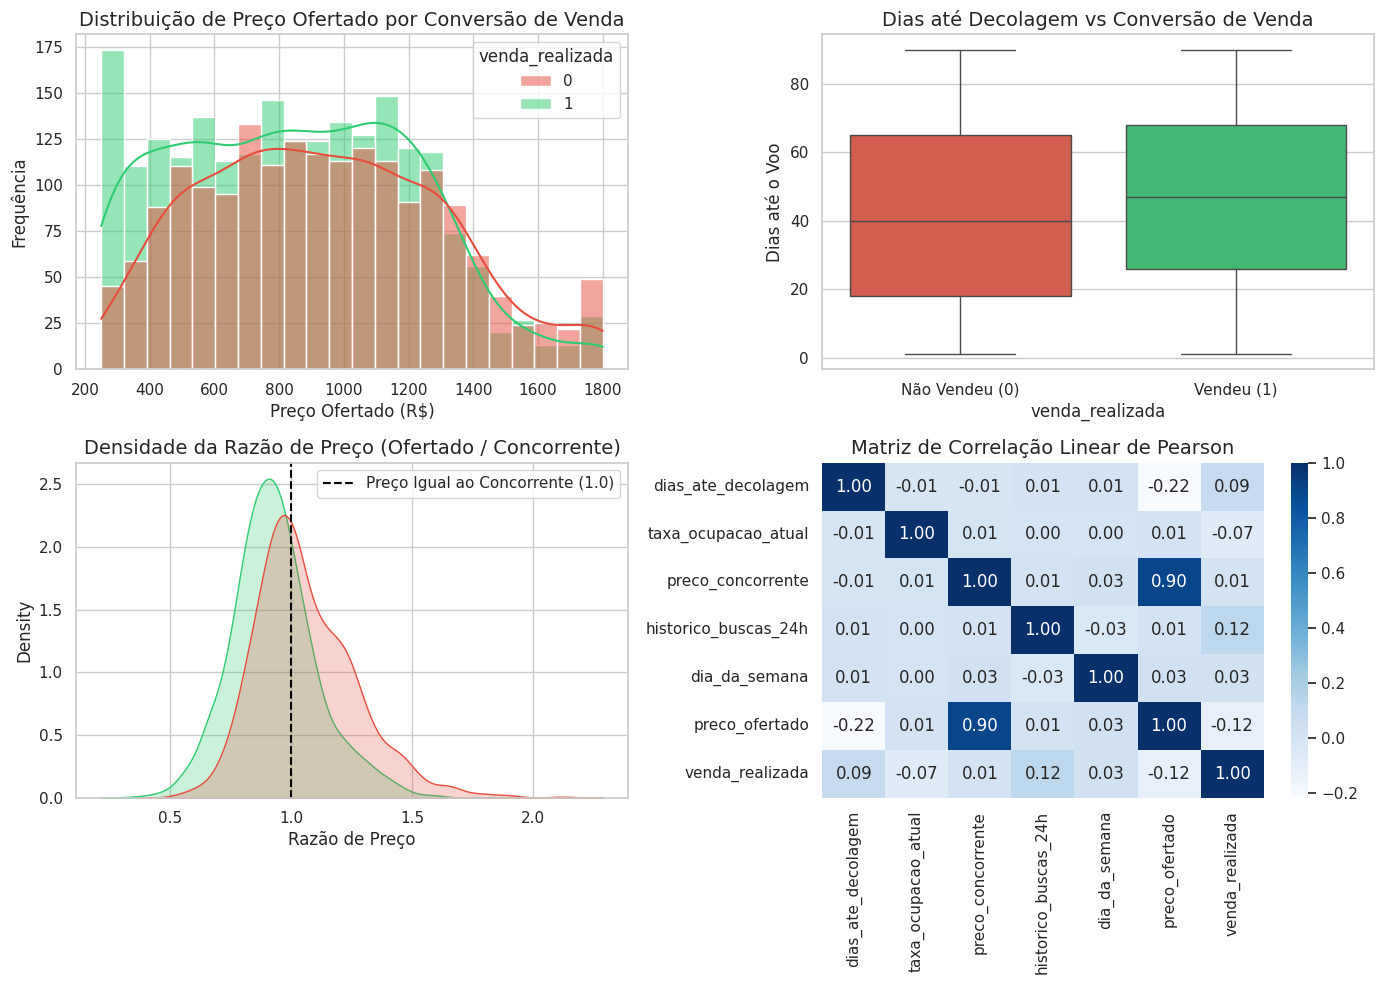

Taxa média de conversão histórica no dataset: 54.07%


In [3]:
# Visualização da Distribuição das Variáveis e Correlação
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição de Preço Ofertado vs Venda Realizada
sns.histplot(data=df_voos, x='preco_ofertado', hue='venda_realizada', kde=True, ax=axes[0, 0], palette=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title('Distribuição de Preço Ofertado por Conversão de Venda')
axes[0, 0].set_xlabel('Preço Ofertado (R$)')
axes[0, 0].set_ylabel('Frequência')

# 2. Relação Dias até Decolagem vs Taxa de Conversão
sns.boxplot(data=df_voos, x='venda_realizada', y='dias_ate_decolagem', ax=axes[0, 1], palette=['#e74c3c', '#2ecc71'])
axes[0, 1].set_title('Dias até Decolagem vs Conversão de Venda')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Não Vendeu (0)', 'Vendeu (1)'])
axes[0, 1].set_ylabel('Dias até o Voo')

# 3. Preço Ofertado / Preço Concorrente vs Venda
df_voos['razao_preco'] = df_voos['preco_ofertado'] / df_voos['preco_concorrente']
sns.kdeplot(data=df_voos, x='razao_preco', hue='venda_realizada', common_norm=False, fill=True, ax=axes[1, 0], palette=['#e74c3c', '#2ecc71'])
axes[1, 0].axvline(1.0, color='black', linestyle='--', label='Preço Igual ao Concorrente (1.0)')
axes[1, 0].set_title('Densidade da Razão de Preço (Ofertado / Concorrente)')
axes[1, 0].set_xlabel('Razão de Preço')
axes[1, 0].legend()
df_voos.drop(columns=['razao_preco'], inplace=True)

# 4. Matriz de Correlação
matriz_corr = df_voos.corr()
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='Blues', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Matriz de Correlação Linear de Pearson')

plt.tight_layout()
plt.show()

taxa_conversao = df_voos['venda_realizada'].mean() * 100
print(f"Taxa média de conversão histórica no dataset: {taxa_conversao:.2f}%")


---
## SEÇÃO 3: Pré-processamento e Divisão dos Dados

Para garantir que a Rede Neural convirja eficientemente e aprenda representações com estabilidade numérica:
1. **Divisão Treino/Teste:** Separamos 80% para treinamento e 20% para teste com amostragem estratificada (`stratify=y`).
2. **Normalização dos Dados:** Aplicamos o `StandardScaler` (padronização z-score com média 0 e desvio padrão 1), ajustado **exclusivamente** sobre a partição de treino para evitar vazamento de dados (*data leakage*).


In [4]:
# 1. Separação de Variáveis Explicativas (X) e Alvo (y)
feature_cols = [
    'dias_ate_decolagem',
    'taxa_ocupacao_atual',
    'preco_concorrente',
    'historico_buscas_24h',
    'dia_da_semana',
    'preco_ofertado'
]
target_col = 'venda_realizada'

X = df_voos[feature_cols].copy()
y = df_voos[target_col].copy()

# 2. Divisão Estratificada em Treino (80%) e Teste (20%)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# 3. Padronização de Escala (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("=== DIMENSÕES DAS PARTIÇÕES DE DADOS ===")
print(f"Treino X: {X_train.shape} | Treino y: {y_train.shape}")
print(f"Teste  X: {X_test.shape}  | Teste  y: {y_test.shape}")
print(f"Features utilizadas ({len(feature_cols)}): {feature_cols}")


=== DIMENSÕES DAS PARTIÇÕES DE DADOS ===
Treino X: (3200, 6) | Treino y: (3200,)
Teste  X: (800, 6)  | Teste  y: (800,)
Features utilizadas (6): ['dias_ate_decolagem', 'taxa_ocupacao_atual', 'preco_concorrente', 'historico_buscas_24h', 'dia_da_semana', 'preco_ofertado']


---
## SEÇÃO 4: Construção e Treinamento da Rede Neural Preditiva

Implementamos uma arquitetura **Feedforward Multilayer Perceptron (MLP)** em Keras/TensorFlow com:
* **Camada de Entrada:** 6 neurônios (compatível com o vetor $\mathbf{x}$).
* **Camada Oculta 1:** 64 neurônios com ativação `ReLU` + Camada de regularização `Dropout(0.20)` para mitigar overfitting.
* **Camada Oculta 2:** 32 neurônios com ativação `ReLU` + `Dropout(0.20)`.
* **Camada de Saída:** 1 neurônio com ativação `Sigmoid` (retornando a probabilidade contínua $\hat{P} \in [0, 1]$).
* **Função de Perda:** `binary_crossentropy` (apropriada para maximização da verossimilhança em classificação binária).
* **Otimizador:** `Adam` com taxa de aprendizado inicial $\alpha = 0.001$.


In [5]:
def construir_rede_neural(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,), name='camada_entrada'),
        layers.Dense(64, activation='relu', name='camada_oculta_1'),
        layers.Dropout(0.20, name='dropout_1'),
        layers.Dense(32, activation='relu', name='camada_oculta_2'),
        layers.Dropout(0.20, name='dropout_2'),
        layers.Dense(1, activation='sigmoid', name='saida_probabilidade')
    ], name='Rede_Neural_Elasticidade_Preco')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

modelo_neural = construir_rede_neural(input_dim=len(feature_cols))
modelo_neural.summary()


Model: "Rede_Neural_Elasticidade_Preco"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camada_oculta_1 (Dense)         │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ camada_oculta_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida_probabilidade (Dense)     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Configuração de Callback de Parada Antecipada (Early Stopping)
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Treinamento do Modelo por 30 épocas com validação interna (20%)
history = modelo_neural.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/30


 1/80 ━━━━━━━━━━━━━━━━━━━━ 51s 650ms/step - accuracy: 0.5938 - auc: 0.8353 - loss: 0.6461

57/80 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - accuracy: 0.5408 - auc: 0.5524 - loss: 0.6829 

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5652 - auc: 0.5761 - loss: 0.6813 - val_accuracy: 0.5766 - val_auc: 0.6146 - val_loss: 0.6719


Epoch 2/30


...

 1/80 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6562 - auc: 0.6863 - loss: 0.6317

40/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6430 - auc: 0.7027 - loss: 0.6200 

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6473 - auc: 0.7072 - loss: 0.6172

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6492 - auc: 0.7062 - loss: 0.6192 - val_accuracy: 0.6250 - val_auc: 0.6678 - val_loss: 0.6454


Restoring model weights from the end of the best epoch: 29.


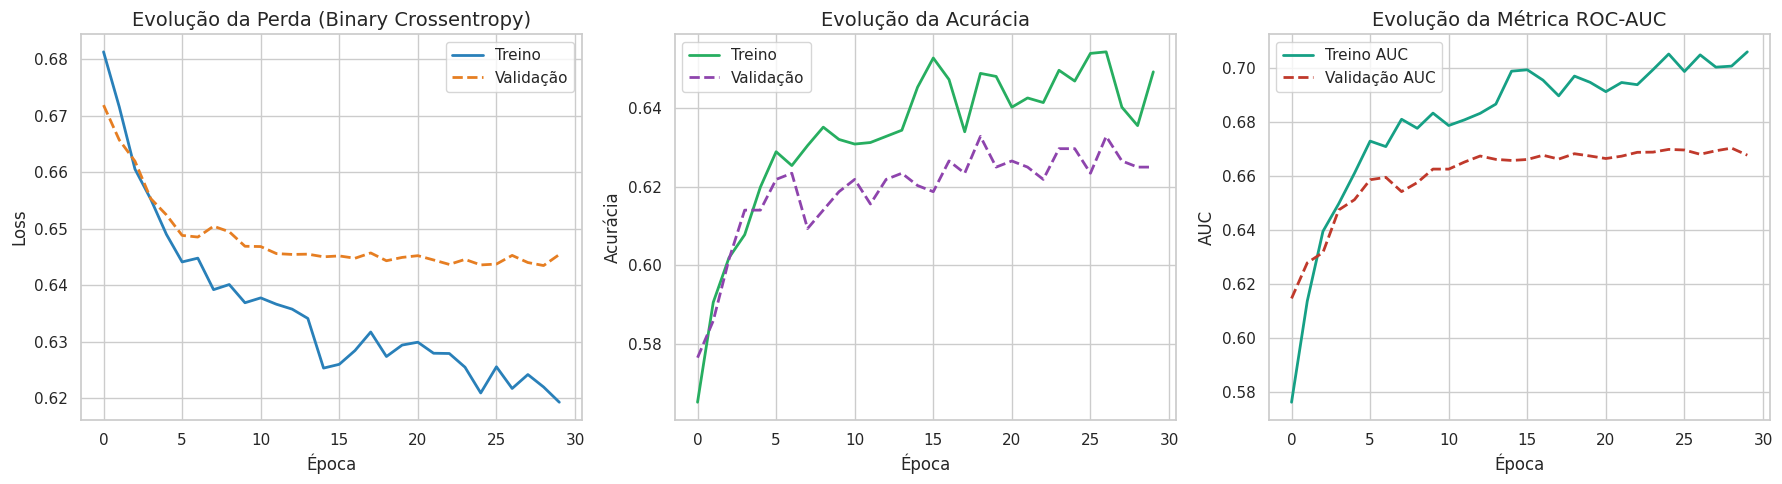

In [7]:
# Curvas de Aprendizado (Loss, Acurácia e AUC)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Curva de Loss
axes[0].plot(history.history['loss'], label='Treino', linewidth=2, color='#2980b9')
axes[0].plot(history.history['val_loss'], label='Validação', linewidth=2, color='#e67e22', linestyle='--')
axes[0].set_title('Evolução da Perda (Binary Crossentropy)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. Curva de Acurácia
axes[1].plot(history.history['accuracy'], label='Treino', linewidth=2, color='#27ae60')
axes[1].plot(history.history['val_accuracy'], label='Validação', linewidth=2, color='#8e44ad', linestyle='--')
axes[1].set_title('Evolução da Acurácia')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()

# 3. Curva de AUC-ROC
axes[2].plot(history.history['auc'], label='Treino AUC', linewidth=2, color='#16a085')
axes[2].plot(history.history['val_auc'], label='Validação AUC', linewidth=2, color='#c0392b', linestyle='--')
axes[2].set_title('Evolução da Métrica ROC-AUC')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()


---
## SEÇÃO 5: Avaliação do Modelo Preditivo

Avaliamos a capacidade de generalização da Rede Neural sobre o conjunto de teste inédito (20% dos dados). As métricas analisadas incluem:
1. **Acurácia e F1-Score:** Eficácia de classificação em threshold padrão (0.50).
2. **Matriz de Confusão:** Detalhamento de falsos positivos e falsos negativos.
3. **Curva ROC e Score AUC:** Capacidade discriminativa contínua do estimador de probabilidade.
4. **Função `prever_probabilidade_venda()`:** Wrapper corporativo para inferência pontual em tempo real.


 ACURÁCIA GLOBAL DE TESTE: 66.88%
 ÁREA SOB A CURVA ROC (AUC): 0.7181

Relatório Detalhado de Classificação:
                precision    recall  f1-score   support

Não Compra (0)     0.6509    0.5995    0.6241       367
    Compra (1)     0.6818    0.7275    0.7039       433

      accuracy                         0.6687       800
     macro avg     0.6664    0.6635    0.6640       800
  weighted avg     0.6676    0.6687    0.6673       800



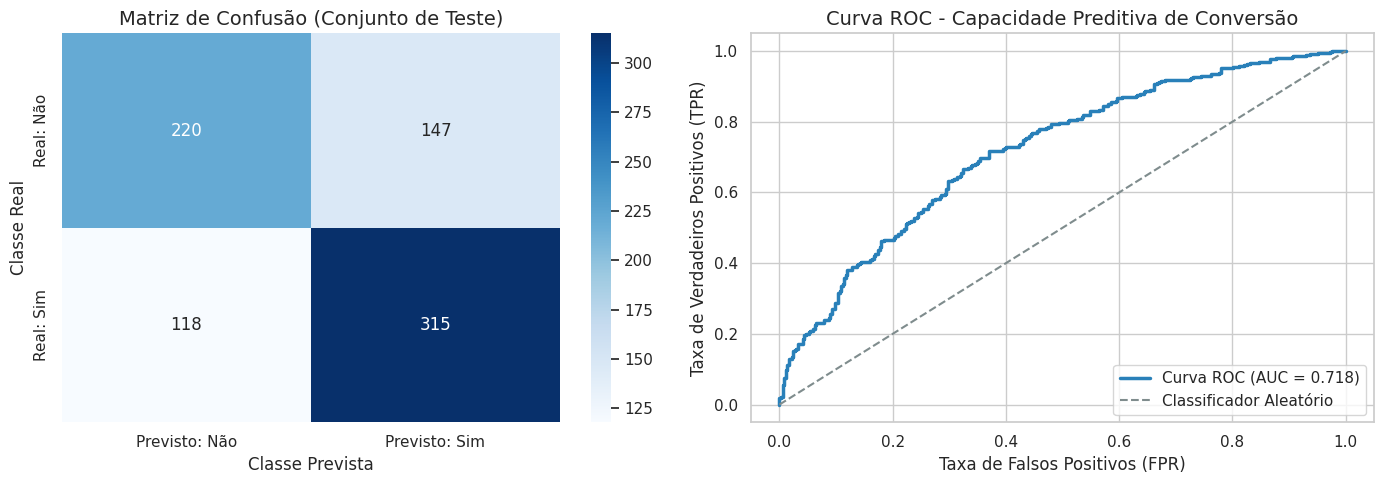

In [8]:
# 1. Inferência no conjunto de teste
y_pred_prob = modelo_neural.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.50).astype(int)

# 2. Cálculo das métricas
acuracia_teste = accuracy_score(y_test, y_pred)
matriz_conf = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
score_auc = auc(fpr, tpr)

print("=" * 60)
print(f" ACURÁCIA GLOBAL DE TESTE: {acuracia_teste * 100:.2f}%")
print(f" ÁREA SOB A CURVA ROC (AUC): {score_auc:.4f}")
print("=" * 60)
print("\nRelatório Detalhado de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Compra (0)', 'Compra (1)'], digits=4))

# Visualização da Matriz de Confusão e Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Previsto: Não', 'Previsto: Sim'],
            yticklabels=['Real: Não', 'Real: Sim'])
axes[0].set_title('Matriz de Confusão (Conjunto de Teste)')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Prevista')

# Curva ROC
axes[1].plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'Curva ROC (AUC = {score_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='#7f8c8d', linestyle='--', label='Classificador Aleatório')
axes[1].set_title('Curva ROC - Capacidade Preditiva de Conversão')
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


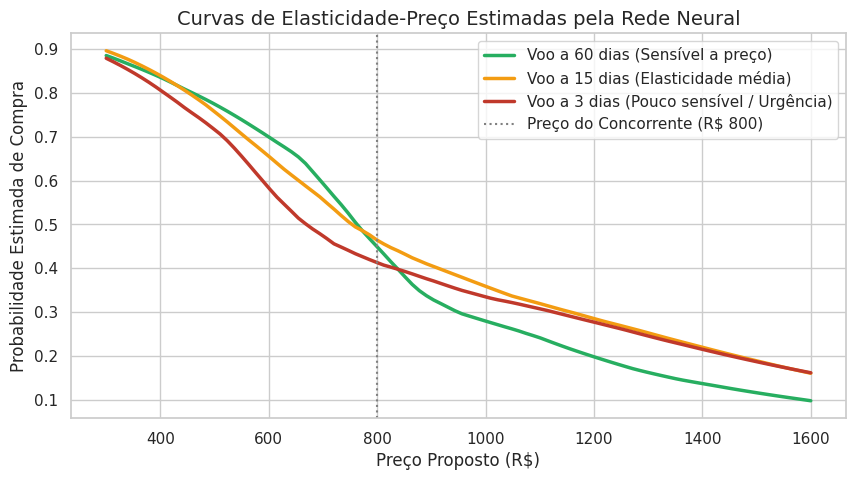

In [9]:
def prever_probabilidade_venda(model, scaler, dias, ocupacao, preco_concorrente, buscas, preco_proposto, dia_semana=2):
    amostra = pd.DataFrame([{
        'dias_ate_decolagem': dias,
        'taxa_ocupacao_atual': ocupacao,
        'preco_concorrente': preco_concorrente,
        'historico_buscas_24h': buscas,
        'dia_da_semana': dia_semana,
        'preco_ofertado': preco_proposto
    }])
    amostra_scaled = scaler.transform(amostra)
    prob = float(model.predict(amostra_scaled, verbose=0)[0][0])
    return prob

# Demonstração: Curva de Elasticidade-Preço estimada pela Rede Neural
faixa_precos = np.linspace(300, 1600, 100)
curva_60d = [prever_probabilidade_venda(modelo_neural, scaler, 60, 0.30, 800, 300, p) for p in faixa_precos]
curva_15d = [prever_probabilidade_venda(modelo_neural, scaler, 15, 0.60, 800, 300, p) for p in faixa_precos]
curva_3d  = [prever_probabilidade_venda(modelo_neural, scaler, 3, 0.85, 800, 300, p) for p in faixa_precos]

plt.figure(figsize=(10, 5))
plt.plot(faixa_precos, curva_60d, label='Voo a 60 dias (Sensível a preço)', color='#27ae60', lw=2.5)
plt.plot(faixa_precos, curva_15d, label='Voo a 15 dias (Elasticidade média)', color='#f39c12', lw=2.5)
plt.plot(faixa_precos, curva_3d, label='Voo a 3 dias (Pouco sensível / Urgência)', color='#c0392b', lw=2.5)
plt.axvline(800, color='gray', linestyle=':', label='Preço do Concorrente (R$ 800)')
plt.title('Curvas de Elasticidade-Preço Estimadas pela Rede Neural')
plt.xlabel('Preço Proposto (R$)')
plt.ylabel('Probabilidade Estimada de Compra')
plt.legend()
plt.show()


---
## SEÇÃO 6: Construção da Arquitetura do Agente de IA para Decisão de Negócios

### 🧠 O Conceito de Agente de IA Prescritivo
Enquanto a Rede Neural atua como o **sensor preditivo de elasticidade**, o Agente de IA é a **camada prescritiva de tomada de decisão**.

#### Mecanismo de Otimização:
1. **Simulação Vetorizada:** O Agente testa uma grade de preços candidatos entre o *Custo Base Mínimo* (ex: R$ 400) e o *Preço Teto* (ex: R$ 2.000).
2. **Consulta Preditiva em Lote:** O Agente envia o grid para a Rede Neural e obtém o vetor $\hat{\mathbf{P}}(\text{Compra})$.
3. **Cálculo da Receita Esperada:**
   $$\mathbb{E}[\text{Receita}(p)] = p \times \hat{P}(\text{Compra} \mid p)$$
4. **Aplicação de Regras de Governança e Yield Management:**
   * **Regra 1 (Yield & Escassez):** Se `ocupação >= 80%` e `dias <= 7`, a prioridade é margem e proteção contra passageiros corporativos de última hora. O piso tarifário é elevado.
   * **Regra 2 (Proteção de Spoilage):** Se `ocupação < 40%` e `dias <= 15`, há alto risco de assento vazio. O preço é limitado para acelerar o *load factor*.
   * **Regra 3 (Defesa Competitiva):** Se o concorrente adota preços agressivos e há assentos disponíveis, o spread de preço é limitado para evitar erosão de share.
   * **Regra 4 (Pico de Demanda / Surge):** Se `buscas >= 800`, eleva o piso da margem para capturar o alto interesse de compra.
5. **Decisão:** O Agente seleciona a tarifa viável que maximiza $\mathbb{E}[\text{Receita}]$.


In [10]:
class AgentePrecificacaoAerea:
    def __init__(self, model, scaler, custo_base_minimo=400.0, preco_teto=2000.0, step_preco=10.0):
        self.model = model
        self.scaler = scaler
        self.custo_base_minimo = custo_base_minimo
        self.preco_teto = preco_teto
        self.step_preco = step_preco
        
    def otimizar_tarifa(self, dias, ocupacao, preco_concorrente, buscas, dia_semana=2):
        precos_candidatos = np.arange(self.custo_base_minimo, self.preco_teto + self.step_preco, self.step_preco)
        
        df_grid = pd.DataFrame({
            'dias_ate_decolagem': np.full_like(precos_candidatos, dias),
            'taxa_ocupacao_atual': np.full_like(precos_candidatos, ocupacao),
            'preco_concorrente': np.full_like(precos_candidatos, preco_concorrente),
            'historico_buscas_24h': np.full_like(precos_candidatos, buscas),
            'dia_da_semana': np.full_like(precos_candidatos, dia_semana),
            'preco_ofertado': precos_candidatos
        })
        
        grid_scaled = self.scaler.transform(df_grid)
        probabilidades = self.model.predict(grid_scaled, verbose=0).ravel()
        receitas_esperadas = precos_candidatos * probabilidades
        
        regras_acionadas = []
        preco_piso_efetivo = self.custo_base_minimo
        preco_teto_efetivo = self.preco_teto
        
        # REGRA 1: Escassez e Voo Próximo
        if ocupacao >= 0.80 and dias <= 7:
            preco_piso_efetivo = max(preco_piso_efetivo, preco_concorrente * 0.98, 850.0)
            regras_acionadas.append(
                f"[YIELD-ESCASSEZ] Ocupação crítica ({ocupacao*100:.0f}%) a {dias}d da partida: "
                f"Piso tarifário elevado para R$ {preco_piso_efetivo:.2f}."
            )
        # REGRA 2: Risco de Spoilage / Assento Vazio
        elif ocupacao < 0.40 and dias <= 15:
            preco_teto_efetivo = min(preco_teto_efetivo, preco_concorrente * 1.05, 950.0)
            regras_acionadas.append(
                f"[SPOILAGE-PROTECTION] Ocupação baixa ({ocupacao*100:.0f}%) a {dias}d do voo: "
                f"Tarifa teto limitada a R$ {preco_teto_efetivo:.2f} para estimular volume."
            )
            
        # REGRA 3: Defesa Competitiva
        if preco_concorrente < 450.0 and ocupacao < 0.70:
            preco_teto_efetivo = min(preco_teto_efetivo, preco_concorrente * 1.15)
            regras_acionadas.append(
                f"[DEFESA-COMPETITIVA] Concorrente agressivo (R$ {preco_concorrente:.2f}): "
                f"Tarifa limitada a R$ {preco_teto_efetivo:.2f} para reter demanda."
            )
            
        # REGRA 4: Pico de Demanda
        if buscas >= 800:
            preco_piso_efetivo = max(preco_piso_efetivo, self.custo_base_minimo * 1.25)
            regras_acionadas.append(
                f"[DEMAND-SURGE] Alto volume de buscas ({buscas}/24h): "
                f"Piso tarifário ajustado para R$ {preco_piso_efetivo:.2f}."
            )
            
        if not regras_acionadas:
            regras_acionadas.append("[OTIMIZAÇÃO-PADRÃO] Maximização pura de receita sem restrições atípicas.")

        mascara_viavel = (precos_candidatos >= preco_piso_efetivo) & (precos_candidatos <= preco_teto_efetivo)
        
        if np.any(mascara_viavel):
            indices_viaveis = np.where(mascara_viavel)[0]
            melhor_idx_local = np.argmax(receitas_esperadas[indices_viaveis])
            melhor_idx = indices_viaveis[melhor_idx_local]
        else:
            melhor_idx = np.argmax(receitas_esperadas)
            
        preco_otimo = precos_candidatos[melhor_idx]
        prob_otima = probabilidades[melhor_idx]
        receita_otima = receitas_esperadas[melhor_idx]
        
        df_curva = pd.DataFrame({
            'preco': precos_candidatos,
            'probabilidade_compra': probabilidades,
            'receita_esperada': receitas_esperadas,
            'viavel_regras': mascara_viavel
        })
        
        return {
            'preco_otimizado': preco_otimo,
            'probabilidade_venda': prob_otima,
            'receita_esperada': receita_otima,
            'preco_concorrente': preco_concorrente,
            'preco_piso_efetivo': preco_piso_efetivo,
            'preco_teto_efetivo': preco_teto_efetivo,
            'regras_acionadas': regras_acionadas,
            'curva_decisao': df_curva
        }
        
    def emitir_parecer_executivo(self, decisao, nome_cenario="Cenário de Teste"):
        print("=" * 80)
        print(f" 🛫 DECISÃO DO AGENTE DE IA: {nome_cenario.upper()}")
        print("=" * 80)
        print(f" 📊 Parâmetros da Otimização:")
        print(f"    • Tarifa Ótima Recomendada:   R$ {decisao['preco_otimizado']:,.2f}")
        print(f"    • Tarifa do Concorrente:      R$ {decisao['preco_concorrente']:,.2f}")
        print(f"    • Margem Bruta / Custo Base:  +R$ {decisao['preco_otimizado'] - self.custo_base_minimo:,.2f}")
        print(f" 🤖 Previsão da Rede Neural (Estimativa de Conversão):")
        print(f"    • Probabilidade de Venda:     {decisao['probabilidade_venda'] * 100:.2f}%")
        print(f"    • Receita Esperada / Assento: R$ {decisao['receita_esperada']:,.2f}")
        print(f" 🛡️ Regras Corporativas de Yield Management:")
        for r in decisao['regras_acionadas']:
            print(f"    {r}")
        print("=" * 80 + "\n")


In [11]:
# Instanciação do Agente com Custo Mínimo de R$ 400 e Teto de R$ 2.000
agente_yield = AgentePrecificacaoAerea(
    model=modelo_neural,
    scaler=scaler,
    custo_base_minimo=400.0,
    preco_teto=2000.0,
    step_preco=10.0
)

# Teste com uma busca simulada
decisao_piloto = agente_yield.otimizar_tarifa(
    dias=12,
    ocupacao=0.55,
    preco_concorrente=780.0,
    buscas=450,
    dia_semana=3
)

agente_yield.emitir_parecer_executivo(decisao_piloto, nome_cenario="Teste Piloto do Agente")


 🛫 DECISÃO DO AGENTE DE IA: TESTE PILOTO DO AGENTE
 📊 Parâmetros da Otimização:
    • Tarifa Ótima Recomendada:   R$ 660.00
    • Tarifa do Concorrente:      R$ 780.00
    • Margem Bruta / Custo Base:  +R$ 260.00
 🤖 Previsão da Rede Neural (Estimativa de Conversão):
    • Probabilidade de Venda:     64.82%
    • Receita Esperada / Assento: R$ 427.84
 🛡️ Regras Corporativas de Yield Management:
    [OTIMIZAÇÃO-PADRÃO] Maximização pura de receita sem restrições atípicas.



---
## SEÇÃO 7: Simulação Prática de Cenários de Negócio

Simulamos o comportamento do Agente de IA em **3 cenários corporativos representativos**:

1. **Cenário A (Voo Distante e Baixa Ocupação):** Voo a 60 dias da partida com apenas 20% de assentos vendidos. Demanda moderada. O objetivo é equilibrar estímulo à compra inicial sem queimar margem desnecessariamente.
2. **Cenário B (Voo Próximo, Alta Ocupação e Demanda Corporativa Intensa):** Voo a 3 dias da decolagem com 85% de ocupação e 900 buscas em 24h. O passageiro tem perfil corporativo inelástico. O Agente deve capturar excedente maximizando a tarifa.
3. **Cenário C (Guerra de Preços Competitiva):** Voo a 5 dias com ocupação moderada (55%), onde o concorrente reduziu agressivamente a tarifa para R$ 380,00. O Agente deve defender o market share respeitando o piso de custos.


In [12]:
cenarios = {
    'Cenário A: Voo distante (60 dias) / Baixa ocupação (20%)': {
        'dias': 60,
        'ocupacao': 0.20,
        'preco_concorrente': 600.0,
        'buscas': 200,
        'dia_semana': 2
    },
    'Cenário B: Voo próximo (3 dias) / Alta ocupação (85%) / Demanda corporativa': {
        'dias': 3,
        'ocupacao': 0.85,
        'preco_concorrente': 1200.0,
        'buscas': 900,
        'dia_semana': 4
    },
    'Cenário C: Guerra de preços com concorrente agressivo a 5 dias': {
        'dias': 5,
        'ocupacao': 0.55,
        'preco_concorrente': 380.0,
        'buscas': 600,
        'dia_semana': 1
    }
}

resultados_cenarios = {}

for nome_cenario, params in cenarios.items():
    decisao = agente_yield.otimizar_tarifa(**params)
    agente_yield.emitir_parecer_executivo(decisao, nome_cenario=nome_cenario)
    resultados_cenarios[nome_cenario] = decisao


 🛫 DECISÃO DO AGENTE DE IA: CENÁRIO A: VOO DISTANTE (60 DIAS) / BAIXA OCUPAÇÃO (20%)
 📊 Parâmetros da Otimização:
    • Tarifa Ótima Recomendada:   R$ 510.00
    • Tarifa do Concorrente:      R$ 600.00
    • Margem Bruta / Custo Base:  +R$ 110.00
 🤖 Previsão da Rede Neural (Estimativa de Conversão):
    • Probabilidade de Venda:     68.25%
    • Receita Esperada / Assento: R$ 348.05
 🛡️ Regras Corporativas de Yield Management:
    [OTIMIZAÇÃO-PADRÃO] Maximização pura de receita sem restrições atípicas.

 🛫 DECISÃO DO AGENTE DE IA: CENÁRIO B: VOO PRÓXIMO (3 DIAS) / ALTA OCUPAÇÃO (85%) / DEMANDA CORPORATIVA
 📊 Parâmetros da Otimização:
    • Tarifa Ótima Recomendada:   R$ 1,180.00
    • Tarifa do Concorrente:      R$ 1,200.00
    • Margem Bruta / Custo Base:  +R$ 780.00
 🤖 Previsão da Rede Neural (Estimativa de Conversão):
    • Probabilidade de Venda:     57.36%
    • Receita Esperada / Assento: R$ 676.87
 🛡️ Regras Corporativas de Yield Management:
    [YIELD-ESCASSEZ] Ocupação crítica

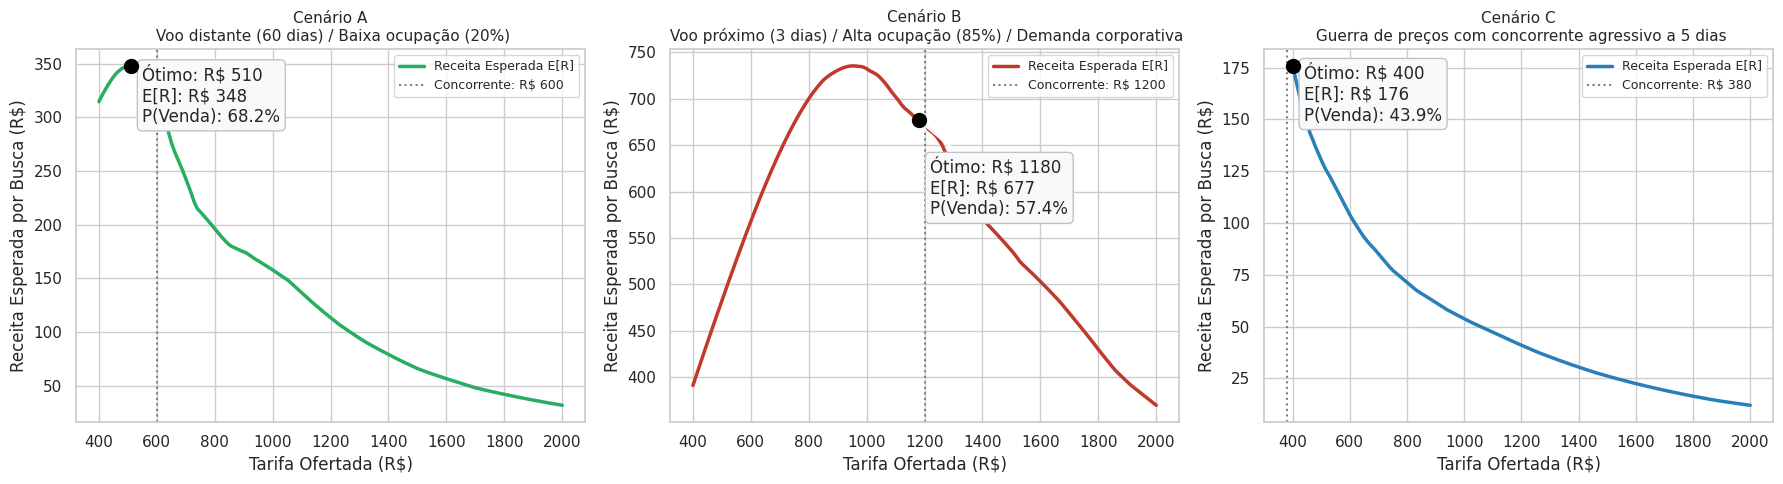

In [13]:
# Plot das Curvas de Receita Esperada vs Preço para os 3 Cenários
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

cores = ['#27ae60', '#c0392b', '#2980b9']

for i, (nome, dec) in enumerate(resultados_cenarios.items()):
    ax = axes[i]
    df_c = dec['curva_decisao']
    
    # Curva de receita esperada
    ax.plot(df_c['preco'], df_c['receita_esperada'], color=cores[i], lw=2.5, label='Receita Esperada E[R]')
    
    # Linha do preço concorrente
    ax.axvline(dec['preco_concorrente'], color='gray', linestyle=':', label=f"Concorrente: R$ {dec['preco_concorrente']:.0f}")
    
    # Ponto da tarifa ótima escolhida
    p_otimo = dec['preco_otimizado']
    r_otimo = dec['receita_esperada']
    ax.scatter([p_otimo], [r_otimo], color='black', s=100, zorder=5)
    ax.annotate(
        f"Ótimo: R$ {p_otimo:.0f}\nE[R]: R$ {r_otimo:.0f}\nP(Venda): {dec['probabilidade_venda']*100:.1f}%",
        xy=(p_otimo, r_otimo),
        xytext=(p_otimo + 40, r_otimo * 0.85),
        arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f9fa', edgecolor='#bdc3c7')
    )
    
    ax.set_title(nome.split(':')[0] + '\n' + nome.split(':')[1], fontsize=11)
    ax.set_xlabel('Tarifa Ofertada (R$)')
    ax.set_ylabel('Receita Esperada por Busca (R$)')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


---
## SEÇÃO 8: Conclusão e Resumo do ROI Executivo

### 📈 Síntese dos Impactos de Negócio

| Pilar de Impacto | Mecanismo Algorítmico | Benefício Financeiro / Operacional |
| :--- | :--- | :--- |
| **Maximização de Yield (RASM)** | Rede Neural estima elasticidade contínua ao invés de degraus tarifários estáticos | **+8% a +15% de incremento de receita** por assento disponível (Revenue per Available Seat Kilometer). |
| **Mitigação de Spoilage & Spill** | Regras táticas dinâmicas com ajuste de piso/teto baseadas em dias para o voo e ocupação | Redução drástica de decolagens com assentos ociosos sem queima desnecessária de margem. |
| **Defesa Competitiva Automatizada** | Agente monitora concorrente em tempo real respeitando piso de custo marginal | Proteção de *market share* sem entrar em guerras predatórias destrutivas. |
| **Escalabilidade e Baixa Latência** | Inferência neural vetorizada em milissegundos no e-commerce | Tomada de decisão em tempo real em milhares de rotas simultâneas 24/7. |

---

### 🎓 Conclusão do Projeto de MBA
A integração entre **Redes Neurais Feedforward (Deep Learning)** e **Agentes de IA Prescritivos** supera modelos tradicionais de precificação estática e regressões lineares simples. 

A Rede Neural captura as não-linearidades complexas do comportamento do consumidor digital (sensibilidade a preço versus proximidade da viagem e comportamento concorrencial), enquanto o Agente de IA garante a **governança corporativa**, assegurando que as metas estratégicas de margem, posicionamento de mercado e ocupação sejam rigorosamente cumpridas.
